# Content-Based Filtering with TF-IDF

This notebook implements the content-based recommendation model for my CM3070 Final Project. It is the third notebook in the pipeline, following the data curation notebook and the feature prototype notebook. The pipeline combines each course's name and institution into a single content string, converts those strings into TF-IDF vectors, computes pairwise cosine similarity, and returns the top-K most similar courses for any given query.

Content-based filtering addresses the cold-start problem that collaborative filtering cannot handle — a new user or a new course with no rating history can still receive or appear in recommendations, because similarity is computed from content alone rather than from user interactions.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Text vectorization and similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Plotting
import matplotlib.pyplot as plt

# Saving the fitted vectorizer to disk for reuse in later notebooks
import pickle

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
# Load the filtered Coursera courses from Notebook 01
courses = pd.read_csv('coursera_courses_filtered.csv')

print(f"Number of courses: {len(courses)}")
print(f"Columns: {list(courses.columns)}")
print(f"\nFirst 5 courses:")
print(courses[['name', 'institution']].head().to_string(index=False))

print(f"\nMissing values per column:")
print(courses.isnull().sum())

Number of courses: 336
Columns: ['name', 'institution', 'course_url', 'course_id']

First 5 courses:
                                                    name               institution
                                        Machine Learning       Stanford University
                          Technical Support Fundamentals                    Google
Become a CBRS Certified Professional Installer by Google Google - Spectrum Sharing
                                       Financial Markets           Yale University
 Programming for Everybody (Getting Started with Python)    University of Michigan

Missing values per column:
name           0
institution    0
course_url     0
course_id      0
dtype: int64


---
## Building the text feature

Each course has a name and an institution. I combine both into a single content string per course, so that both title keywords and provider information contribute to the similarity score.

In [3]:
# Combine course name and institution into a single text feature
courses['content'] = courses['name'].fillna('') + ' ' + courses['institution'].fillna('')

# Preview the new column
print("Sample content strings:")
for i in range(5):
    print(f"  {i}: {courses['content'].iloc[i]}")

print(f"\nAverage content length (characters): {courses['content'].str.len().mean():.1f}")
print(f"Shortest content: {courses['content'].str.len().min()} chars")
print(f"Longest content: {courses['content'].str.len().max()} chars")

Sample content strings:
  0: Machine Learning Stanford University
  1: Technical Support Fundamentals Google
  2: Become a CBRS Certified Professional Installer by Google Google - Spectrum Sharing
  3: Financial Markets Yale University
  4: Programming for Everybody (Getting Started with Python) University of Michigan

Average content length (characters): 64.2
Shortest content: 25 chars
Longest content: 157 chars


---
## TF-IDF vectorization

Convert each course's content string into a TF-IDF vector: words that are important to a course but rare across the catalogue receive high weight. The vectorizer settings are:
- English stopwords removed
- Unigrams and bigrams (one- and two-word phrases)
- Top 5,000 features by frequency
- Minimum document frequency of 2 (drop words appearing in only one course)

In [4]:
# Fit the TF-IDF vectorizer on all course content
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(courses['content'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} courses")
print(f"  → {tfidf_matrix.shape[1]} unique words/phrases in the vocabulary")

# Show a sample of the vocabulary to make sure it looks reasonable
vocab = tfidf.get_feature_names_out()
print(f"\nFirst 20 vocabulary terms: {list(vocab[:20])}")
print(f"Random sample of 20 terms: {list(np.random.RandomState(42).choice(vocab, 20, replace=False))}")

TF-IDF matrix shape: (336, 499)
  → 336 courses
  → 499 unique words/phrases in the vocabulary

First 20 vocabulary terms: ['19', 'accounting', 'accounting data', 'accounting fundamentals', 'accounting university', 'administration', 'advanced', 'agile', 'ai', 'ai ibm', 'ai medical', 'alberta', 'amazon', 'amazon web', 'amsterdam', 'analysis', 'analysis python', 'analysis stanford', 'analysis university', 'analytics']
Random sample of 20 terms: ['university new', 'cloud', 'international', 'financial accounting', 'introduction user', 'são', 'erasmus university', 'california davis', 'paulo', 'ai ibm', 'crash course', 'lund university', 'product management', 'georgia institute', 'covid', 'sql', 'university geneva', 'autodesk', 'duke', 'web services']


---
## Cosine similarity matrix

Now that every course is a TF-IDF vector, I compute pairwise cosine similarity between all courses. Cosine similarity returns a value between:
- 0 → no shared important words
- 1 → identical content

I chose cosine similarity over raw distance because it ignores document length, so a short title with strong keyword overlap can still register as similar to a longer content string. The result is a symmetric 336×336 matrix where entry [i, j] is the similarity between course i and course j.

In [5]:
# Compute pairwise cosine similarity between all courses
sim_matrix = cosine_similarity(tfidf_matrix)

print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Diagonal values (should all be 1.0): {sim_matrix.diagonal()[:5]}")
print(f"Matrix min: {sim_matrix.min():.4f}")
print(f"Matrix max: {sim_matrix.max():.4f}")
print(f"Matrix mean (excluding diagonal): {(sim_matrix.sum() - sim_matrix.trace()) / (sim_matrix.size - len(sim_matrix)):.4f}")

Similarity matrix shape: (336, 336)
Diagonal values (should all be 1.0): [1. 1. 1. 1. 1.]
Matrix min: 0.0000
Matrix max: 1.0000
Matrix mean (excluding diagonal): 0.0275


> The average pairwise similarity of 0.0275 confirms the catalogue is diverse — most course pairs share very few important words. This is what we want, since recommendations built on this matrix will be genuinely informative rather than returning near-duplicates.

---
## Visualizing the similarity distribution

A histogram of all pairwise similarity scores shows how the catalogue is distributed.

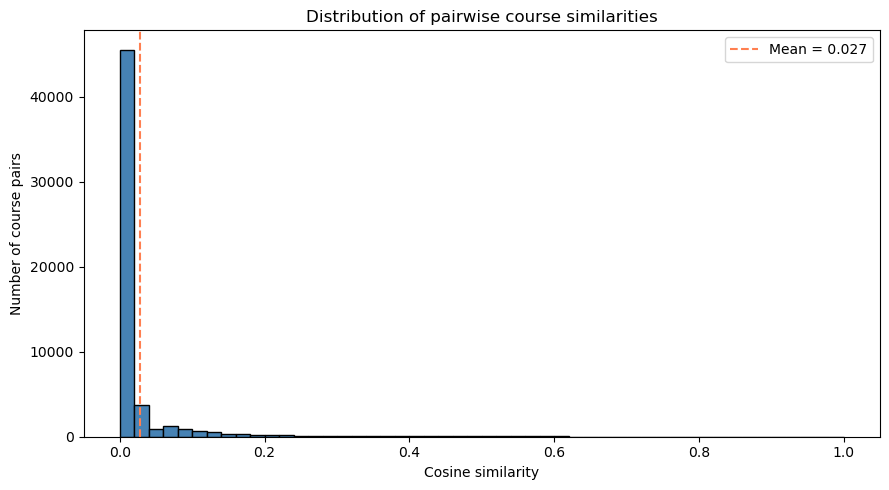

Total course pairs: 56,280
Pairs with similarity > 0.5: 475
Pairs with similarity > 0.8: 61


In [6]:
# Get all pairwise similarities (upper triangle only, excluding the diagonal)
upper_triangle = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(upper_triangle, bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Number of course pairs')
ax.set_title('Distribution of pairwise course similarities')
ax.axvline(upper_triangle.mean(), color='coral', linestyle='--',
           label=f'Mean = {upper_triangle.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total course pairs: {len(upper_triangle):,}")
print(f"Pairs with similarity > 0.5: {(upper_triangle > 0.5).sum():,}")
print(f"Pairs with similarity > 0.8: {(upper_triangle > 0.8).sum():,}")

---
## Recommendation function

For any given course, look up its row in the similarity matrix, drop the course itself, and return the top-K courses with the highest similarity scores.

In [7]:
def recommend_similar_courses(course_name, top_k=10):
    """Return the top-K courses most similar to the given course name."""
    # Find the course in the catalogue
    matches = courses[courses['name'].str.lower() == course_name.lower()]
    if len(matches) == 0:
        return f"Course '{course_name}' not found in catalogue."
    idx = matches.index[0]

    # Build a table with the similarity score for every course
    scores = pd.DataFrame({
        'course_index': range(len(courses)),
        'similarity': sim_matrix[idx]
    })

    # Drop the course itself, then keep the top K
    scores = scores[scores['course_index'] != idx]
    scores = scores.nlargest(top_k, 'similarity')

    # Attach the course name and institution to the result
    result = courses.iloc[scores['course_index'].values][['name', 'institution']].copy()
    result['similarity'] = scores['similarity'].round(3).values
    return result.reset_index(drop=True)

## Testing the model on three well-known courses

I test the recommendation function on three courses from different topic areas — machine learning, finance, and programming — to check whether the recommendations are topically coherent across domains.

In [8]:
print("Recommendations for: Machine Learning (Stanford)\n")
print(recommend_similar_courses("Machine Learning").to_string(index=False))

print("\n" + "="*70 + "\n")
print("Recommendations for: Financial Markets (Yale)\n")
print(recommend_similar_courses("Financial Markets").to_string(index=False))

print("\n" + "="*70 + "\n")
print("Recommendations for: Programming for Everybody (Getting Started with Python)\n")
print(recommend_similar_courses("Programming for Everybody (Getting Started with Python)").to_string(index=False))

Recommendations for: Machine Learning (Stanford)

                                                                name              institution  similarity
                     Fundamentals of Machine Learning for Healthcare      Stanford University       0.825
Divide and Conquer, Sorting and Searching, and Randomized Algorithms      Stanford University       0.716
                                            Machine Learning for All     University of London       0.522
                                       Introduction to Clinical Data      Stanford University       0.515
                                    Introduction to Machine Learning          Duke University       0.507
                 Machine Learning Foundations: A Case Study Approach University of Washington       0.441
                                             Organizational Analysis      Stanford University       0.432
                    Probabilistic Graphical Models 1: Representation      Stanford University       0.

---
## Visualizing top-10 recommendations for a sample course

A horizontal bar chart of the top-10 similar courses for "Machine Learning" (Stanford) makes the ranking easier to read than the text output.

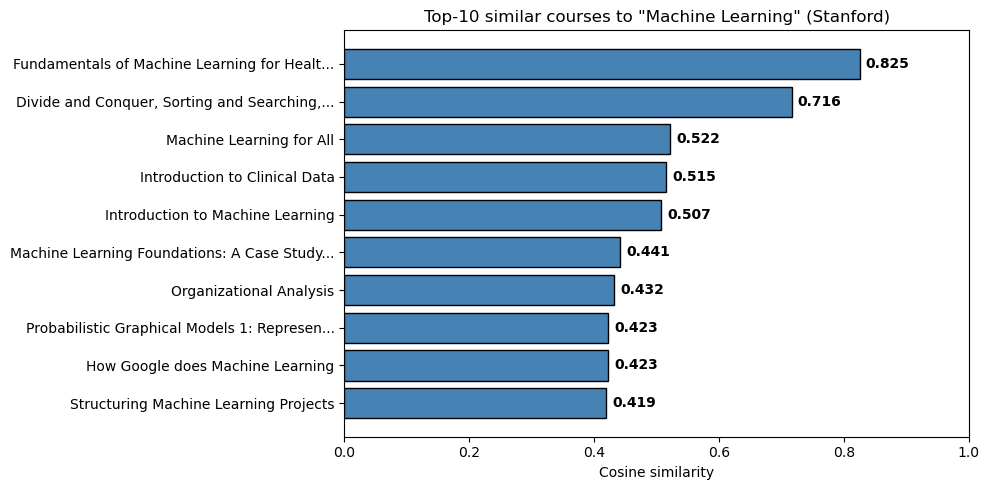

In [9]:
# Get top-10 recommendations for Machine Learning
recs = recommend_similar_courses("Machine Learning", top_k=10)

fig, ax = plt.subplots(figsize=(10, 5))
# Reverse the list so the highest bar sits at the top
labels = [name if len(name) < 45 else name[:42] + '...' for name in recs['name']][::-1]
scores = recs['similarity'].values[::-1]

ax.barh(labels, scores, color='steelblue', edgecolor='black')
ax.set_xlabel('Cosine similarity')
ax.set_title('Top-10 similar courses to "Machine Learning" (Stanford)')
ax.set_xlim(0, 1)

for i, v in enumerate(scores):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Observations from the qualitative tests

The model returns topically-coherent recommendations for all three test queries:
- Machine learning courses cluster together
- Finance courses cluster together
- Python courses cluster together

However, two limitations of TF-IDF are visible from the results:
1. Some recommendations are driven by institution overlap rather than topic — for example "Divide and Conquer" from Stanford appears in the Machine Learning results purely because it shares "Stanford University" with the query.
2. Some are driven by shared surface phrases like "Getting Started" rather than actual topic overlap, as seen in the Python results.

These limitations motivate moving to a semantic embedding model in the next stage of the project, which will capture meaning beyond shared surface words.

---
## Saving the model artifacts

Save the fitted TF-IDF vectorizer, the similarity matrix, and the courses table (with the new content column) to disk, so that later stages of the project can load them without recomputing.

In [10]:
# Save the fitted vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save the similarity matrix
np.save('content_similarity_matrix.npy', sim_matrix)

# Save the courses dataframe with the content column, so other stages
# use the same course order the similarity matrix relies on
courses.to_csv('coursera_courses_with_content.csv', index=False)

print("Saved: tfidf_vectorizer.pkl")
print("Saved: content_similarity_matrix.npy")
print("Saved: coursera_courses_with_content.csv")

Saved: tfidf_vectorizer.pkl
Saved: content_similarity_matrix.npy
Saved: coursera_courses_with_content.csv
